In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPool1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, AdamW

In [3]:
import pandas as pd
from google.colab import drive

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# Define paths based on your previous cell comments
train_path = '/content/drive/MyDrive/datasets/final_cleaned/train.csv'
val_path   = '/content/drive/MyDrive/datasets/final_cleaned/val.csv'
test_path  = '/content/drive/MyDrive/datasets/final_cleaned/test.csv'

# Load datasets
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

# Extract features (text) and labels (sentiment)
X_train = df_train['text'].astype(str)
Y_train = df_train['label_id']

X_val = df_val['text'].astype(str)
Y_val = df_val['label_id']

X_test = df_test['text'].astype(str)
Y_test = df_test['label_id']

print(f"Training rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")

Mounted at /content/drive
Training rows: 87912
Validation rows: 4689
Test rows: 5793


In [31]:
df_train['label_id'].value_counts()

,count
label_id,
2,45897
1,24782
0,17233


In [4]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes=3)
Y_val = to_categorical(Y_val, num_classes=3)
Y_test  = to_categorical(Y_test, num_classes=3)

In [5]:
# PARAMETERS
MAX_VOCAB = 20000
max_len = 50
EMB_DIM = 300

In [6]:

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [7]:

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

In [8]:
EMBEDDING_PATH = '/content/drive/MyDrive/Embeddings/wiki-news-300d-1M.vec'

# Load fastText embeddings
embeddings_index = {}
with open(EMBEDDING_PATH, 'r', encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        vector = np.asarray(values[1:], dtype=np.float32)
        embeddings_index[word] = vector

word_index = tokenizer.word_index
num_words = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMB_DIM), dtype=np.float32)

hits = 0
for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1

print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'Vocab coverage: {hits}/{num_words} ({hits/num_words:.1%})')

Embedding matrix shape: (20000, 300)
Vocab coverage: 18911/20000 (94.6%)


In [9]:
embedding_dim = 300
word_index = tokenizer.word_index
vocab_size = min(len(word_index) + 1, 20000)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

In [83]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False  # important initially
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [84]:
print(embedding_matrix.shape)
print(embedding_matrix[1].shape)

(20000, 300)
(300,)


In [146]:
# MODEL
from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(embedding_layer)
model.add(SpatialDropout1D(0.4))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(GlobalMaxPool1D())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(3, activation='softmax'))

In [147]:
# COMPILE
model.compile(
    loss='categorical_crossentropy',
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

In [148]:
from sklearn.utils.class_weight import compute_class_weight

In [149]:
balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=df_train['label_id'].astype(int)
)

softened_weights = np.sqrt(balanced_weights)
# Re-normalize so they average to 1.0
softened_weights = softened_weights / softened_weights.mean()
# softened_weights = balanced_weights

In [150]:
balanced_weights, softened_weights

(array([1.70045842, 1.18247115, 0.6384731 ]),
 array([1.22616452, 1.02249457, 0.75134091]))

In [151]:
# class_weights = {
#     0: 1.6,   # Negative → penalize mistakes more
#     1: 1.3,   # Positive
#     2: 0.8,   # Neutral → penalize less
# }

class_weights = {
    0: 1,   # Negative → penalize mistakes more
    1: .9,   # Positive
    2: .8   # Neutral → penalize less
}

class_weights = dict(zip(range(3), softened_weights))
class_weights

{0: np.float64(1.2261645152065557),
 1: np.float64(1.022494572293386),
 2: np.float64(0.7513409125000586)}

In [152]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    Y_train,
    validation_data=(X_val_pad, Y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight = class_weights
)

Epoch 1/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - accuracy: 0.6233 - loss: 0.8248 - val_accuracy: 0.6419 - val_loss: 0.8250
Epoch 2/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.6564 - loss: 0.7633 - val_accuracy: 0.6428 - val_loss: 0.8198
Epoch 3/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.6683 - loss: 0.7417 - val_accuracy: 0.6688 - val_loss: 0.7830
Epoch 4/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 0.6778 - loss: 0.7251 - val_accuracy: 0.6413 - val_loss: 0.8371
Epoch 5/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.6849 - loss: 0.7077 - val_accuracy: 0.6803 - val_loss: 0.7635
Epoch 6/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.6912 - loss: 0.6980 - val_accuracy: 0.6784 - val_loss: 0.7566
Epoch 7/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.6980 - loss: 0.6849 - val_accuracy: 0.6807 - val_loss: 0.7542
Epoch 8/20
2748/2748 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 0.7025 -

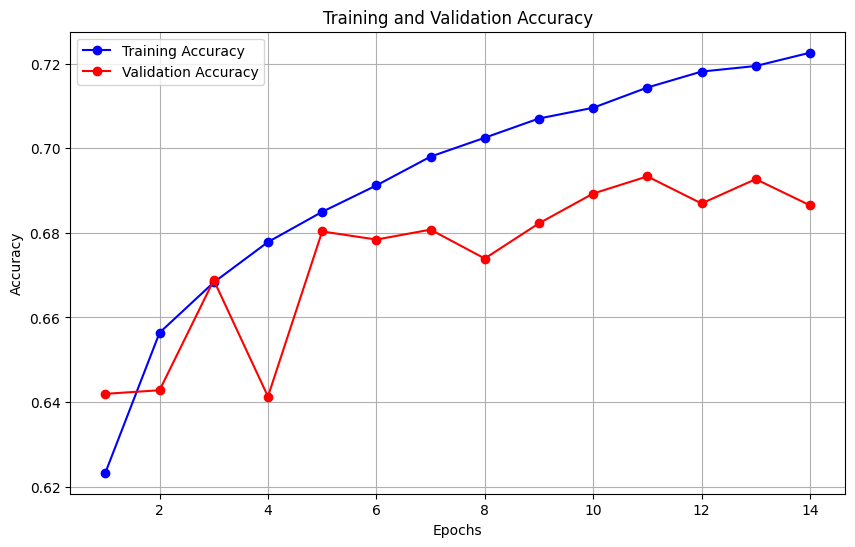

In [153]:
import matplotlib.pyplot as plt

# Extract accuracy values from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [154]:
y_pred = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [155]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_true, y_pred_classes)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7037804246504402


In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.74      0.67      0.70      2107
           1       0.75      0.74      0.75      2107
           2       0.61      0.70      0.65      1579

    accuracy                           0.70      5793
   macro avg       0.70      0.70      0.70      5793
weighted avg       0.71      0.70      0.70      5793



[[1407  295  405]
 [ 250 1560  297]
 [ 246  223 1110]]


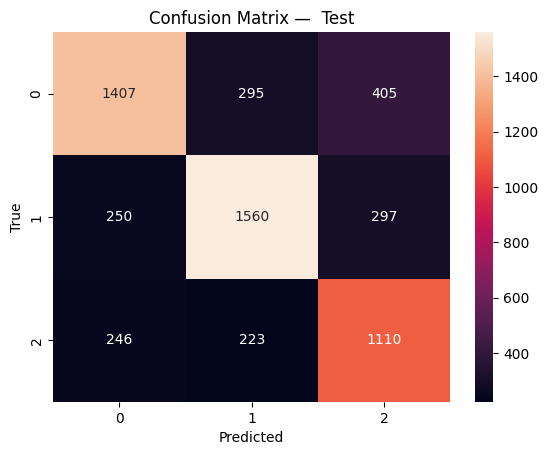

In [157]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix —  Test')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

In [120]:
import re
def clean_text(text):
    text = text.lower()

    # fix common encoding issues
    text = text.replace("Â´", "'")

    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mentions (@user)
    text = re.sub(r"@\w+", "", text)

    # remove hashtags symbol ONLY (#happy → happy)
    text = re.sub(r"#", "", text)

    return text

In [121]:
def normalize_repeats(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

In [122]:
def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z_\s]", "", text)
    return text

In [123]:
def preprocess_pipeline(text):
    text = clean_text(text)
    text = normalize_repeats(text)
    text = remove_special_chars(text)
    return text

text = "I can actually see the effort here"
clean_textt = preprocess_pipeline(text)
clean_textt

'i can actually see the effort here'

In [124]:
def predict_sentiment(text):
  text = preprocess_pipeline(text)

  seq = tokenizer.texts_to_sequences([text])
  padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating = 'post')
  pred = model.predict(padded)
  label = np.argmax(pred, axis=1)[0]
  return {
      'label': label_map[label],
      'score': float(pred[0][label]),
      'preds': pred
  }

In [125]:
label_map = {
    0: "negative",
    1: "positive",
    2: "neutral"

}

In [162]:
predict_sentiment("The product was bad but the service was good")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


{'label': 'positive',
 'score': 0.9868645071983337,
 'preds': array([[0.01052311, 0.9868645 , 0.0026124 ]], dtype=float32)}

In [163]:
import pickle

# Save the model
model.save('/content/drive/MyDrive/Artifacts/Model/bilstm_sentiment_v1.keras')

# Save the tokenizer — THIS IS CRITICAL, people forget this
with open('/content/drive/MyDrive/Artifacts/Tokenizer/tokenizer_v1.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save your config so you remember exact settings
config = {
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'version': 'v1_simple_sentences',
    'notes': 'BiLSTM, no lemmatization, no handle_negation, simple sentences nailed'
}

with open('config_v1.json', 'w') as f:
    import json
    json.dump(config, f, indent=2)

print("All saved.")

All saved.
